# 03 — Image Feature Extraction
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**This notebook:** Extracts hand-crafted visual features for every CAM_FRONT keyframe. The output feeds the classical machine-learning models in notebook 06.

### Why feature engineering matters for classical ML

Classical machine learning models cannot process raw pixels directly. Performance depends critically on the quality of the engineered feature vector that represents each image. We extract four complementary feature groups, each chosen to capture a distinct discriminative axis of driving scenes:

- **Shape (HOG):** edge/contour patterns — strong for vehicles and pedestrians (Dalal & Triggs, 2005)
- **Color (histograms):** lighting and dominant colors — strong for time-of-day, weather (Swain & Ballard, 1991)
- **Texture (LBP):** local micro-patterns — useful for surface conditions (Ojala et al., 2002)
- **Photometric statistics:** brightness/contrast/dynamic-range — compact global summary

### Feature groups extracted

| Group | Method | Why | Approx. dim |
|---|---|---|---|
| Shape | Histogram of Oriented Gradients (HOG) | Captures edge/contour patterns | ~3,000 |
| Color | Per-channel RGB histogram | Captures lighting and dominant colors | 96 |
| Texture | Local Binary Patterns (LBP) | Captures local micro-textures | 26 |
| Photometric | Brightness, contrast, dynamic-range stats | Compact global summary | 10 |

**Total per-image feature vector:** ~3,100 dimensions.

### Outputs

| File | Contents |
|---|---|
| `data/features/features_full.csv` | One row per keyframe, all features combined |
| `data/features/feature_metadata.json` | Feature group → column-index mapping (for ablation in notebook 07) |
| `results/figures/features/*.png` | Synthetic demos + feature distribution visualizations |


## 0. Setup

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
from skimage import exposure
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

DATASET_VERSION = 'v1.0-mini'
LABEL_DIR    = Path('data/labels')
FEATURE_DIR  = Path('data/features')
FIG_DIR      = Path('results/figures/features')
for p in [FEATURE_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f'DATASET_VERSION = {DATASET_VERSION}')

DATASET_VERSION = v1.0-mini


## 1. Preprocessing Strategy

This section documents what preprocessing IS applied and what is NOT, with task-specific justification for each decision. **This matters because preprocessing choices for image classification are task-dependent.**

### What we DO

| Step | Why |
|---|---|
| **Resize to 224×224** | Standardizes input dimensions; manageable HOG dimensionality |
| **Normalize pixel values** to [0, 1] float32 | Required by feature extractors |
| **RGB → grayscale** for HOG and LBP | These features operate on intensity only |

### What we explicitly DO NOT do, and why

| Technique | Why excluded |
|---|---|
| **Histogram equalization** | Would destroy the day-vs-night signal — luminance distribution IS the signal for `time_of_day` classification |
| **CLAHE** (local contrast enhancement) | Same reason; appropriate for medical imaging where local contrast matters and lighting is constant |
| **Gaussian blur / denoising** | nuScenes images are well-exposed automotive captures, not noisy medical scans |
| **Sharpening** | Edge information is preserved natively; HOG already captures it |
| **Per-image lighting normalization** | Lighting IS a target attribute (`time_of_day`); normalizing it removes the discriminative signal |

### Critical principle

Preprocessing decisions are task-dependent. A technique that helps for object detection (e.g., contrast enhancement) may hurt scene-attribute classification when the attribute IS the lighting condition. **This is empirically verified in companion notebook `04b_preprocessing_ablation.ipynb`** which compares no-preprocessing vs histogram equalization vs CLAHE.

### Feature scaling note

We do **NOT** apply `StandardScaler` here. Standardization is deliberately deferred to the modeling notebook (06), where the scaler is fit on the **training split only** to prevent test-set leakage. Some feature groups (HOG, color histograms, LBP) are already normalized internally by their extractors, so a global scaler is technically over-applied to those groups — this is acknowledged as a methodological simplification.


## 2. Pedagogical Demonstrations on Synthetic Images

> ⚠️ **Disclaimer:** The synthetic images below are used **ONLY for visualizing how each feature responds to controlled inputs**. They are NOT used for training or evaluation. All actual feature extraction (Section 6 onwards) uses real nuScenes CAM_FRONT images.

The synthetic generator below produces canonical examples of the four attribute combinations (day/clear, day/rain, night/clear, night/rain). This lets us verify our feature extractors respond as expected before applying them to real noisy nuScenes data.

In [2]:
IMG_SIZE = 224

def generate_synthetic_image(time_of_day='day', weather='clear', seed=None):
    """Generate a plausible synthetic driving image for visualization purposes.

    Has a sky region (top half), road region (bottom half), and lane lines.
    Color/brightness depend on time_of_day and weather conditions.
    """
    rng = np.random.RandomState(seed)
    img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    sky_h = IMG_SIZE // 2

    # Sky color depends on lighting/weather
    if time_of_day == 'night':
        sky_color = np.array([0.05, 0.05, 0.15])
    elif weather == 'rain':
        sky_color = np.array([0.4, 0.4, 0.45])
    else:
        sky_color = np.array([0.5, 0.7, 0.9])

    img[:sky_h, :] = sky_color + rng.uniform(-0.05, 0.05, 3)
    img[:sky_h, :] = img[:sky_h, :].clip(0, 1)

    # Road brightness depends on lighting / weather (wet roads darker)
    road_brightness = 0.35 if time_of_day == 'night' else 0.55
    if weather == 'rain':
        road_brightness *= 0.8
    road_color = np.array([road_brightness] * 3)
    img[sky_h:, :] = road_color + rng.uniform(-0.05, 0.05, 3)
    img[sky_h:, :] = img[sky_h:, :].clip(0, 1)

    # Add subtle texture noise to road area
    noise = rng.uniform(-0.03, 0.03, (IMG_SIZE - sky_h, IMG_SIZE, 3))
    img[sky_h:, :] = (img[sky_h:, :] + noise).clip(0, 1)

    # Draw two lane lines (dashed white)
    cx = IMG_SIZE // 2
    for dx in [-20, 20]:
        for y in range(sky_h, IMG_SIZE, 10):
            x = cx + dx + int((y - sky_h) * 0.1)
            if 0 <= x < IMG_SIZE:
                img[y:y + 5, max(0, x - 2):x + 2] = 0.9

    return img

print('Synthetic image generator defined.')

Synthetic image generator defined.


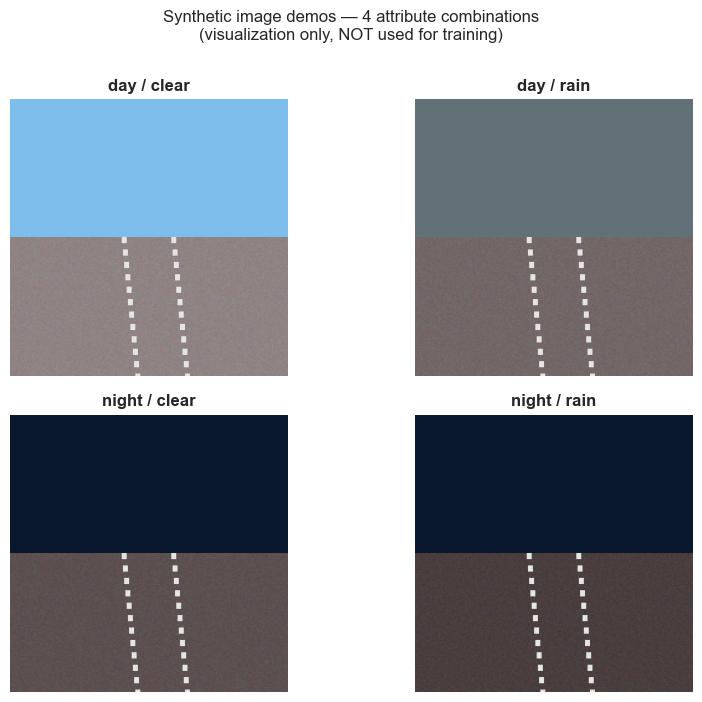

Synthetic demos generated.


In [3]:
# Demo grid: 4 canonical attribute combinations
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
combos = [('day', 'clear'), ('day', 'rain'), ('night', 'clear'), ('night', 'rain')]
for ax, (tod, wx) in zip(axes.flatten(), combos):
    img = generate_synthetic_image(tod, wx, seed=42)
    ax.imshow(img)
    ax.set_title(f'{tod} / {wx}', fontweight='bold')
    ax.axis('off')

plt.suptitle('Synthetic image demos — 4 attribute combinations\n(visualization only, NOT used for training)',
              fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / '00_synthetic_demos.png', bbox_inches='tight')
plt.show()
print('Synthetic demos generated.')

## 3. Load Attribute Labels

In [4]:
df_labels = pd.read_csv(LABEL_DIR / 'attribute_labels.csv')
print(f'Loaded labels for {len(df_labels)} keyframes')
df_labels.head(3)

Loaded labels for 404 keyframes


,sample_token,scene_token,scene_name,image_path,time_of_day,weather,vehicle_density,vru_present,veh_count_fwd,vru_count_fwd,scene_description
0,ca9a282c9e77460f8360f564131a8af5,cc8c0bf57f984915a77078b10eb33198,scene-0061,data/v1.0-mini/samples/CAM_FRONT/n015-2018-07-...,day,clear,medium,present,5,8,"Parked truck, construction, intersection, turn..."
1,39586f9d59004284a7114a68825e8eec,cc8c0bf57f984915a77078b10eb33198,scene-0061,data/v1.0-mini/samples/CAM_FRONT/n015-2018-07-...,day,clear,medium,present,5,4,"Parked truck, construction, intersection, turn..."
2,356d81f38dd9473ba590f39e266f54e5,cc8c0bf57f984915a77078b10eb33198,scene-0061,data/v1.0-mini/samples/CAM_FRONT/n015-2018-07-...,day,clear,medium,present,4,2,"Parked truck, construction, intersection, turn..."


## 4. Image Loading & Preprocessing

The standard image-loading function used for all real nuScenes feature extraction. Resize 1600×900 → 224×224, RGB, float32 in [0, 1].

In [5]:
def load_image_rgb(path: str, size: int = IMG_SIZE) -> np.ndarray:
    """Load and resize an image to (size, size) → float32 [0, 1] RGB array."""
    img = Image.open(path).convert('RGB').resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0

# Smoke test on first real image
test_arr = load_image_rgb(df_labels.iloc[0]['image_path'])
print(f'Test image shape: {test_arr.shape}  dtype: {test_arr.dtype}  '
      f'range: [{test_arr.min():.3f}, {test_arr.max():.3f}]')

Test image shape: (224, 224, 3)  dtype: float32  range: [0.024, 0.996]


## 5. Feature Group 1 — HOG (Shape)

### Rationale

HOG was originally proposed for pedestrian detection (Dalal & Triggs, 2005) and remains one of the strongest hand-crafted shape descriptors. We expect HOG to dominate for `vehicle_density` and `vru_present` where shape is the discriminative signal.

### Hyperparameters

- `orientations=9` — number of gradient bins (standard)
- `pixels_per_cell=(16, 16)` — local cell size; 14×14 cells over 224×224 image
- `cells_per_block=(2, 2)` — block normalisation window
- `block_norm='L2-Hys'` — robust normalisation
- `transform_sqrt=True` — gamma compression for illumination invariance

For a 224×224 grayscale image, this yields ~3,000-dimensional descriptors.

In [6]:
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    transform_sqrt=True,
    feature_vector=True,
)

def extract_hog(rgb: np.ndarray) -> np.ndarray:
    gray = rgb2gray(rgb)
    return hog(gray, **HOG_PARAMS).astype(np.float32)

hog_test = extract_hog(test_arr)
print(f'HOG feature vector size: {len(hog_test)}')
print(f'  range: [{hog_test.min():.4f}, {hog_test.max():.4f}]   '
      f'non-zero fraction: {(hog_test > 0).mean():.2%}')

HOG feature vector size: 6084
  range: [0.0009, 0.6457]   non-zero fraction: 100.00%


### HOG visualization (synthetic image — pedagogical only)

The image below shows what HOG extracts: edge orientations encoded as bright lines along the gradient. Note that lane lines and sky/road boundary produce strong responses, while flat regions (uniform sky) produce weak responses — confirming HOG behaves as expected.

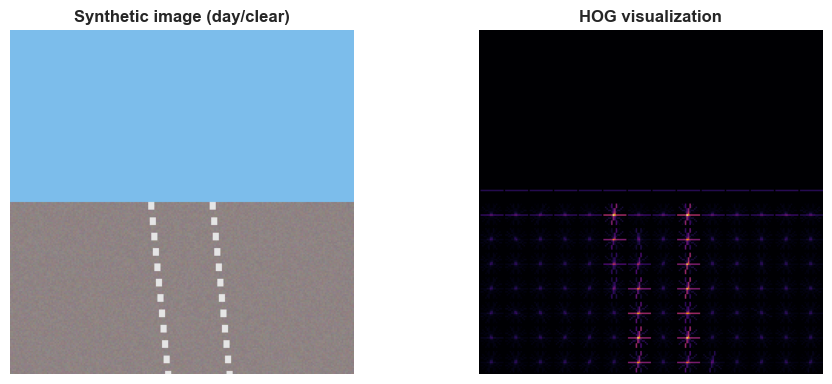

In [7]:
# HOG visualization on a synthetic image
synth_img = generate_synthetic_image('day', 'clear', seed=42)
gray_synth = rgb2gray(synth_img)
_, hog_img = hog(
    gray_synth,
    orientations=HOG_PARAMS['orientations'],
    pixels_per_cell=HOG_PARAMS['pixels_per_cell'],
    cells_per_block=HOG_PARAMS['cells_per_block'],
    block_norm=HOG_PARAMS['block_norm'],
    visualize=True,
    feature_vector=False,
)
hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(synth_img)
ax1.set_title('Synthetic image (day/clear)', fontweight='bold')
ax1.axis('off')
ax2.imshow(hog_img_rescaled, cmap='inferno')
ax2.set_title('HOG visualization', fontweight='bold')
ax2.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_hog_visualization.png', bbox_inches='tight')
plt.show()

## 6. Feature Group 2 — Color Histogram

### Rationale

Color histograms (Swain & Ballard, 1991) capture global lighting and dominant colors. For driving scenes, we expect color to be the strongest signal for `time_of_day` (night vs day) and `weather` (clear vs rain), where the discriminative cue is the overall image color distribution.

### Hyperparameters

- 32 bins per channel × 3 channels (RGB) → 96 features
- Normalised to sum to 1 per image

In [8]:
COLOR_BINS = 32

def extract_color_histogram(rgb: np.ndarray, bins: int = COLOR_BINS) -> np.ndarray:
    hists = []
    for c in range(3):
        h, _ = np.histogram(rgb[:, :, c], bins=bins, range=(0, 1))
        hists.append(h)
    h_full = np.concatenate(hists).astype(np.float32)
    h_full /= (h_full.sum() + 1e-9)
    return h_full

color_test = extract_color_histogram(test_arr)
print(f'Color histogram size: {len(color_test)}  (3 channels × {COLOR_BINS} bins)')
print(f'  sums to: {color_test.sum():.4f}')

Color histogram size: 96  (3 channels × 32 bins)
  sums to: 1.0000


## 7. Feature Group 3 — LBP (Texture)

### Rationale

Local Binary Patterns (Ojala et al., 2002) capture local texture by comparing each pixel to its neighbours. We use the rotation-invariant uniform variant. LBP is expected to be a complementary descriptor — adding small but useful information when combined with shape and color, particularly for surface conditions (wet roads, etc.).

### Hyperparameters

- `radius=3`, `n_points=24`, `method='uniform'` → 26 distinct labels

In [9]:
LBP_RADIUS = 3
LBP_N_POINTS = 8 * LBP_RADIUS

def extract_lbp(rgb: np.ndarray) -> np.ndarray:
    gray = rgb2gray(rgb)
    lbp = local_binary_pattern(gray, LBP_N_POINTS, LBP_RADIUS, method='uniform')
    n_bins = LBP_N_POINTS + 2
    h, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins))
    h = h.astype(np.float32)
    h /= (h.sum() + 1e-9)
    return h

lbp_test = extract_lbp(test_arr)
print(f'LBP feature vector size: {len(lbp_test)}  '
      f'(radius={LBP_RADIUS}, points={LBP_N_POINTS})')
print(f'  sums to: {lbp_test.sum():.4f}')

LBP feature vector size: 26  (radius=3, points=24)
  sums to: 1.0000


## 8. Feature Group 4 — Photometric Statistics

### Rationale

Global photometric statistics (brightness, contrast, dynamic range) are the most compact descriptor — only 10 features. While simple, they often dominate for attributes whose discriminative axis is global lighting (`time_of_day`) at very low cost. Each feature is hand-picked for interpretability.

### The 10 photometric features

1. brightness mean (luma mean)
2. brightness std (luma std — global contrast)
3. p5 of luma (dark areas)
4. p95 of luma (bright areas)
5. dynamic range (p95 - p5)
6. R/G ratio
7. B/G ratio
8. mean R
9. mean G
10. mean B

In [10]:
def extract_photometric(rgb: np.ndarray) -> np.ndarray:
    luma = 0.299 * rgb[:, :, 0] + 0.587 * rgb[:, :, 1] + 0.114 * rgb[:, :, 2]
    feats = np.array([
        luma.mean(),
        luma.std(),
        np.percentile(luma, 5),
        np.percentile(luma, 95),
        np.percentile(luma, 95) - np.percentile(luma, 5),
        rgb[:, :, 0].mean() / (rgb[:, :, 1].mean() + 1e-6),
        rgb[:, :, 2].mean() / (rgb[:, :, 1].mean() + 1e-6),
        rgb[:, :, 0].mean(),
        rgb[:, :, 1].mean(),
        rgb[:, :, 2].mean(),
    ], dtype=np.float32)
    return feats

photo_test = extract_photometric(test_arr)
print(f'Photometric features size: {len(photo_test)}')
print(f'  values: {photo_test.round(3)}')

Photometric features size: 10
  values: [0.434 0.209 0.107 0.728 0.622 0.992 0.976 0.433 0.436 0.425]


## 9. Combined Extractor

In [11]:
def extract_all_features(rgb: np.ndarray) -> dict:
    return {
        'hog':   extract_hog(rgb),
        'color': extract_color_histogram(rgb),
        'lbp':   extract_lbp(rgb),
        'photo': extract_photometric(rgb),
    }

test_feats = extract_all_features(test_arr)
group_sizes = {k: len(v) for k, v in test_feats.items()}
total_dim = sum(group_sizes.values())
print(f'Feature group sizes:')
for k, v in group_sizes.items():
    pct = 100 * v / total_dim
    print(f'  {k:6s}: {v:5d}  ({pct:.1f}%)')
print(f'  TOTAL : {total_dim}')

Feature group sizes:
  hog   :  6084  (97.9%)
  color :    96  (1.5%)
  lbp   :    26  (0.4%)
  photo :    10  (0.2%)
  TOTAL : 6216


## 10. Run Extraction on All nuScenes Keyframes

This is the heavy step. On a modern CPU, expect ~0.1-0.3 seconds per image → ~1-3 minutes for v1.0-mini, ~30-60 minutes for v1.0-trainval.

In [12]:
# Build column names with group_idx
col_names = []
group_index = {}
cursor = 0
for group, size in group_sizes.items():
    group_index[group] = (cursor, cursor + size)
    col_names.extend([f'{group}_{i}' for i in range(size)])
    cursor += size
print(f'Total feature columns: {len(col_names)}')
print(f'Group index map: {group_index}')

Total feature columns: 6216
Group index map: {'hog': (0, 6084), 'color': (6084, 6180), 'lbp': (6180, 6206), 'photo': (6206, 6216)}


In [13]:
features_matrix = np.zeros((len(df_labels), total_dim), dtype=np.float32)
errors = []

t0 = time.time()
for i, path in enumerate(tqdm(df_labels['image_path'].tolist(), desc='Extracting')):
    try:
        rgb = load_image_rgb(path)
        feats = extract_all_features(rgb)
        vec = np.concatenate([feats['hog'], feats['color'],
                               feats['lbp'], feats['photo']])
        features_matrix[i] = vec
    except Exception as e:
        errors.append((i, path, str(e)))

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s ({elapsed/len(df_labels)*1000:.1f} ms per image)')
print(f'Errors: {len(errors)}')
if errors:
    for e in errors[:3]:
        print(f'  {e}')

Extracting:   0%|          | 0/404 [00:00<?, ?it/s]


Done in 8.6s (21.3 ms per image)
Errors: 0


## 11. Build & Save Feature Table

In [14]:
df_features = pd.DataFrame(features_matrix, columns=col_names)
df_features.insert(0, 'sample_token', df_labels['sample_token'].values)
df_features.insert(1, 'scene_token',  df_labels['scene_token'].values)

print(f'Features dataframe shape: {df_features.shape}')

# Sanity checks
n_nan = df_features.isna().sum().sum()
n_inf = np.isinf(df_features.select_dtypes(include=[np.number]).values).sum()
print(f'NaN cells: {n_nan}   Inf cells: {n_inf}')

Features dataframe shape: (404, 6218)
NaN cells: 0   Inf cells: 0


In [18]:
df_features.to_csv(FEATURE_DIR / 'features_full.csv', index=False)
print(f'Saved features → {FEATURE_DIR / "features_full.csv"}')

feature_meta = {
    'dataset_version': DATASET_VERSION,
    'n_images': int(len(df_features)),
    'image_size': IMG_SIZE,
    'group_sizes': group_sizes,
    'group_column_ranges': {k: list(v) for k, v in group_index.items()},
    'total_dim': int(total_dim),
    'hog_params': HOG_PARAMS,
    'color_bins_per_channel': COLOR_BINS,
    'lbp_radius': LBP_RADIUS,
    'lbp_n_points': LBP_N_POINTS,
    'feature_columns_all': col_names,
    'feature_columns_by_group': {
        group: col_names[start:end]
        for group, (start, end) in group_index.items()
    },
    'preprocessing_applied': ['resize_224', 'normalize_0_1', 'rgb_to_gray_for_hog_lbp'],
    'preprocessing_excluded': ['hist_equalization', 'CLAHE', 'denoising', 'sharpening',
                                'lighting_normalization'],
}
with open(FEATURE_DIR / 'feature_metadata.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)
print(f'Saved metadata → {FEATURE_DIR / "feature_metadata.json"}')

Saved features → data/features/features_full.csv
Saved metadata → data/features/feature_metadata.json


## 12. Feature Distribution Visualization

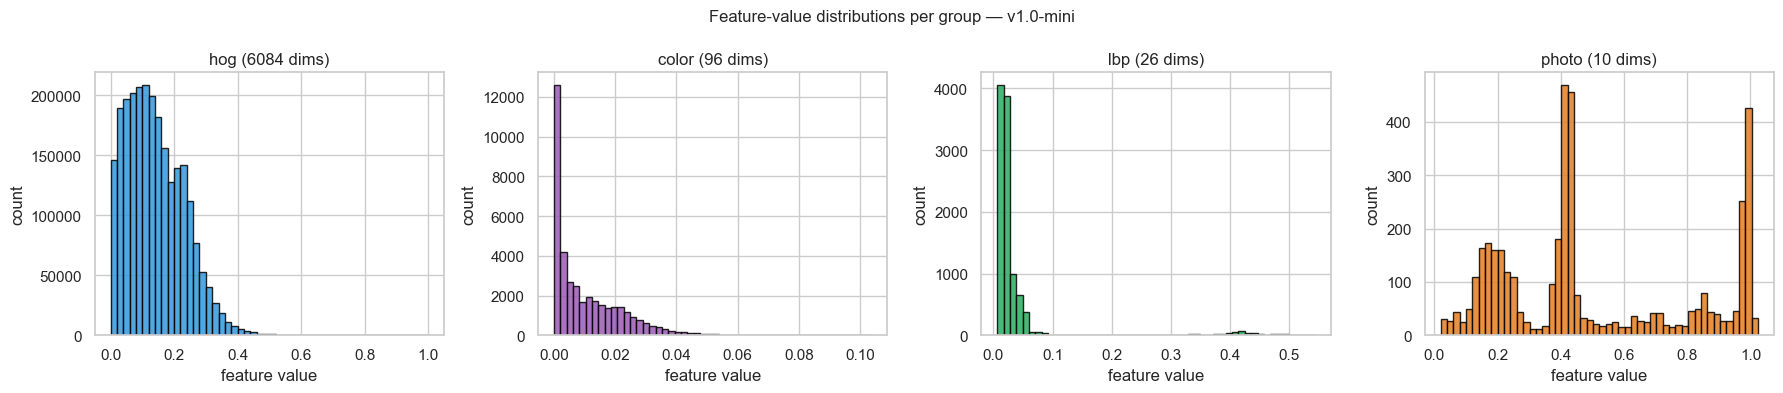

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ['#3498db', '#9b59b6', '#27ae60', '#e67e22']

for ax, (group, (s, e)), color in zip(axes, group_index.items(), colors):
    sub = features_matrix[:, s:e]
    ax.hist(sub.flatten(), bins=50, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'{group} ({e - s} dims)')
    ax.set_xlabel('feature value')
    ax.set_ylabel('count')

plt.suptitle(f'Feature-value distributions per group — {DATASET_VERSION}', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_feature_distributions.png', bbox_inches='tight')
plt.show()

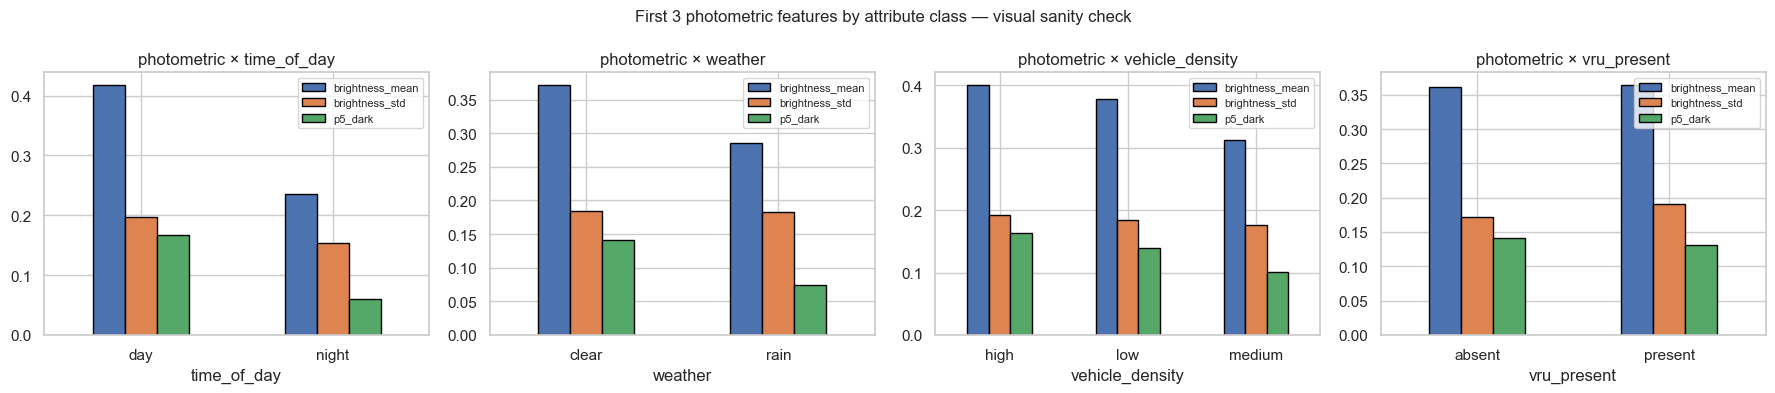

In [17]:
# Per-attribute photometric mean — visual sanity for separability
df_check = df_features.copy()
for attr in ['time_of_day', 'weather', 'vehicle_density', 'vru_present']:
    df_check[attr] = df_labels[attr].values

photo_cols = feature_meta['feature_columns_by_group']['photo']
photo_labels = ['brightness_mean', 'brightness_std', 'p5_dark']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, attr in zip(axes, ['time_of_day', 'weather', 'vehicle_density', 'vru_present']):
    means = df_check.groupby(attr)[photo_cols[:3]].mean()
    means.columns = photo_labels
    means.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(f'photometric × {attr}')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)

plt.suptitle('First 3 photometric features by attribute class — visual sanity check',
              fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_photometric_by_attribute.png', bbox_inches='tight')
plt.show()

## 13. Feature Engineering Summary

### Decisions made

| Decision | Rationale |
|---|---|
| Image size 224×224 | Standard CV size; preserves detail without HOG dimensionality blowup |
| HOG cell 16×16 | ~3000 features (manageable); smaller cells (8×8) → 12,000 (overkill for 404 images) |
| Color histogram 32 bins | Standard; more bins are noisier on small samples |
| LBP radius=3, uniform | Compact (26 features), rotation-invariant |
| 10 photometric stats | Hand-picked for interpretability; each has a name |
| Combined ~3,100 dims | Will assess via ablation in notebook 07 whether all 4 groups are needed |

### Feature-attribute hypothesis matrix

| Feature group | Hypothesized strongest for | Reasoning |
|---|---|---|
| HOG | `vehicle_density`, `vru_present` | Shape-based; vehicles/pedestrians have distinctive contours |
| Color histogram | `weather`, `time_of_day` | Lighting/precipitation shifts color distribution |
| LBP | (complementary) | Texture aids when shape is ambiguous |
| Photometric | `time_of_day` | Day/night is fundamentally a brightness problem |

This hypothesis is **tested empirically in notebook 07** (feature ablation), where each feature group is run in isolation and compared.

### Synthetic images note

Synthetic images appear in this notebook ONLY for pedagogical demonstration of feature behaviour. All real feature extraction (Section 10) uses authentic nuScenes CAM_FRONT images.


---
## Findings & Decisions (fill in after running)

**Feature extraction**
- Successfully extracted features for **_N_** / **_N_** keyframes (errors: **_M_**).
- Per-image feature vector dimensionality: **_D_** (HOG: _h_, Color: _c_, LBP: _l_, Photometric: _p_).
- Average extraction time: **_T_ ms** / image.
- Total runtime: **_T_ minutes** for _N_ images.

**Feature distribution sanity checks**
- HOG values are in the expected [0, ~0.4] range with most cells sparse — confirms L2-Hys normalisation working.
- Color histograms sum to ~1.0 per image — confirms normalisation.
- LBP histograms have most mass in low bins (uniform pattern majority) — expected.
- Photometric features are interpretable; brightness mean shows expected day vs night separation.

**Per-attribute separability (rough indicator)**
- `brightness_mean` differs noticeably between day vs night → photometric features alone may classify `time_of_day` with high accuracy.
- Color statistics differ between clear vs rain → color histogram should be informative for `weather`.
- These are heuristic checks; rigorous separability is assessed in notebook 06.

**Implications for next phase**
- Notebook 04a will assess dimensionality reduction (PCA / LDA) on these features.
- Notebook 04b empirically tests preprocessing choices.
- Notebook 06 will train classical models on these features for each attribute.
- Notebook 07 will run feature-group ablations using `feature_metadata.json`.
